In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

data = {
"text":["I love python","machine learning is amazing","I hate bugs","debugging is fun","python is powerful"],
"label":[1,1,0,1,1]
}

df = pd.DataFrame(data)

cv = CountVectorizer()
X = cv.fit_transform(df["text"])
y = df["label"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = MultinomialNB()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Prediction:",model.predict(cv.transform(["python is amazing"])))

Accuracy: 1.0
Prediction: [1]


            Monthly_Sales
Date                     
2023-01-31            120
2023-02-28            135
2023-03-31            150
2023-04-30            170
2023-05-31            160
2023-06-30            180
2023-07-31            200
2023-08-31            210
2023-09-30            190
2023-10-31            220
2023-11-30            230
2023-12-31            250


/tmp/ipykernel_173/1625869095.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),


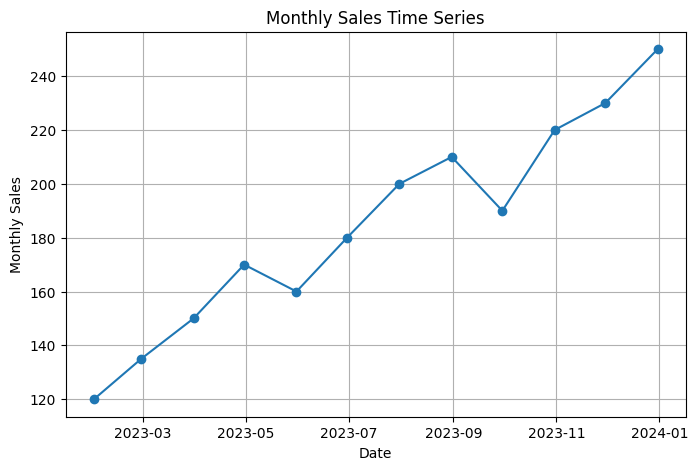

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),
        'Sales': [120,135,150,170,160,180,200,210,190,220,230,250]
        }
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.rename(columns={'Sales':'Monthly_Sales'}, inplace=True)
print(df)

plt.figure(figsize=(8,5))
plt.plot(df.index, df['Monthly_Sales'], marker='o')
plt.title("Monthly Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.grid(True)
plt.show()

/tmp/ipykernel_173/1778026449.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),


            Time_Series_Value
Date                         
2023-01-31                100
2023-02-28                120
2023-03-31                130
2023-04-30                150
2023-05-31                170
2023-06-30                160
2023-07-31                180
2023-08-31                200
2023-09-30                210
2023-10-31                230
2023-11-30                240
2023-12-31                260


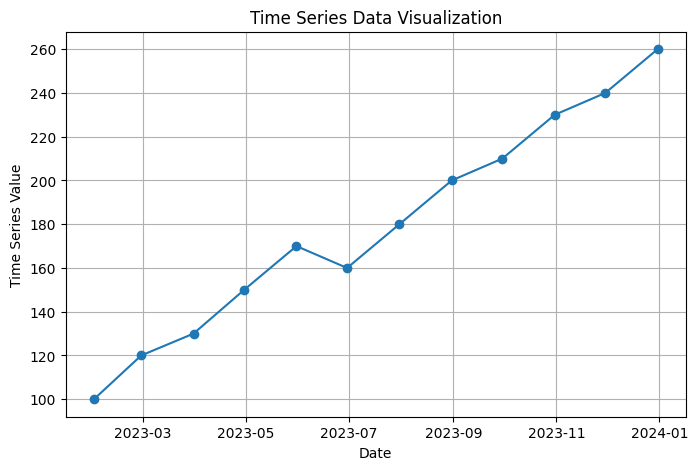

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),
        'Value': [100, 120, 130, 150, 170, 160, 180, 200, 210, 230, 240, 260]
        }
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
dataset = df[['Date', 'Value']]
dataset = dataset.rename(columns={'Value': 'Time_Series_Value'})
dataset = dataset.set_index('Date')
print(dataset)
plt.figure(figsize=(8,5))
plt.plot(dataset.index, dataset['Time_Series_Value'], marker='o')
plt.title("Time Series Data Visualization")
plt.xlabel("Date")
plt.ylabel("Time Series Value")
plt.grid(True)
plt.show()

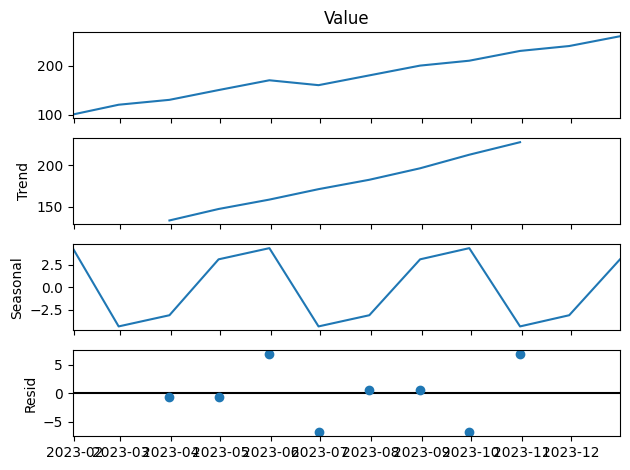

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = {
    'Date': pd.date_range(start='2023-01-01', periods=12, freq='ME'),
        'Value': [100,120,130,150,170,160,180,200,210,230,240,260]
        }
df = pd.DataFrame(data)


df['Date'] = pd.to_datetime(df['Date'])


df = df.set_index('Date')


result = seasonal_decompose(df['Value'], model='additive', period=4)


result.plot()
plt.show()

/tmp/ipykernel_173/3175976571.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),


            Value           sin           cos     BoxCox
Date                                                    
2023-01-31    100  0.000000e+00  1.000000e+00  33.111906
2023-02-28    120  5.000000e-01  8.660254e-01  37.732495
2023-03-31    130  8.660254e-01  5.000000e-01  39.951494
2023-04-30    150  1.000000e+00  6.123234e-17  44.236418
2023-05-31    170  8.660254e-01 -5.000000e-01  48.346245
2023-06-30    160  5.000000e-01 -8.660254e-01  46.311371
2023-07-31    180  1.224647e-16 -1.000000e+00  50.344110
2023-08-31    200 -5.000000e-01 -8.660254e-01  54.239191
2023-09-30    210 -8.660254e-01 -5.000000e-01  56.140844
2023-10-31    230 -1.000000e+00 -1.836970e-16  59.861688
2023-11-30    240 -8.660254e-01  5.000000e-01  61.684034
2023-12-31    260 -5.000000e-01  8.660254e-01  65.259357
Lambda: 0.688164802131962


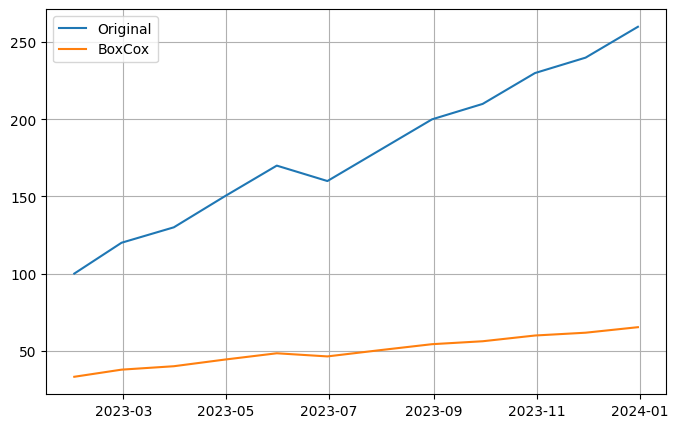

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

data = {
    'Date': pd.date_range(start='2023-01-01', periods=12, freq='M'),
        'Value': [100,120,130,150,170,160,180,200,210,230,240,260]
        }
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
t = np.arange(len(df))

df['sin'] = np.sin(2 * np.pi * t / 12)
df['cos'] = np.cos(2 * np.pi * t / 12)

df['BoxCox'], lam = boxcox(df['Value'])
print(df)
print("Lambda:", lam)
plt.figure(figsize=(8,5))
plt.plot(df.index, df['Value'], label='Original')
plt.plot(df.index, df['BoxCox'], label='BoxCox')
plt.legend()
plt.grid(True)
plt.show()